# UV Sweep — How does the noise filter change with the instrument?

Reproduces the 6-panel figure from `output_higher res.png` and then sweeps
instrument characteristics to see what happens to the surviving modes.

Panels:
- **(a)** UV coverage density — baseline count histogram
- **(b)** Signal vs noise power in `k_perp` (1D)
- **(c)** 1D Wiener filter (ratio from (b))
- **(d)** 2D noise power `P_noise(k_perp, k_par)`
- **(e)** Wiener filter `f_noise(k_perp, k_par)`
- **(f)** Final filter with wedge `f_total = f_wedge × f_noise`

In [11]:
%load_ext autoreload
%autoreload 2
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from astropy import units as un

import py21cmfast as p21c
from tuesday.core import observe_coeval

from src.noise_filters import (
    build_hera_observation,
    compute_2d_ps,
    empirical_noise_2d,
    wiener_filter,
    wedge_mask,
    baseline_lengths,
)

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

N_NOISE_REAL = 5   # realizations for P_noise estimation

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Simulate a clean 21cm box (one per run)

The signal is fixed; only the observation changes in the sweep.

In [12]:
BOX_LEN = 300      # Mpc
DIM = 512
HII_DIM = 256
REDSHIFT = 8.0
H_PARAM = 0.6736   # for h/Mpc axis labels
WEDGE_SLOPE = 1.0

inputs = p21c.InputParameters(
    simulation_options=p21c.SimulationOptions(
        BOX_LEN=BOX_LEN, DIM=DIM, HII_DIM=HII_DIM,
    ),
    random_seed=1,
)
coeval = p21c.run_coeval(inputs=inputs, out_redshifts=[REDSHIFT])[0]
bt = coeval.brightness_temp  # mK
print(f'brightness_temp: shape={bt.shape}, std={bt.std():.3f} mK')

brightness_temp: shape=(256, 256, 256), std=8.481 mK


In [13]:
# Clean signal P(k_perp, k_par) — used by every configuration
kp_c, kpar_c, P_signal, cnt = compute_2d_ps(bt, BOX_LEN)
print(f'k_perp range: {kp_c.min():.3f} - {kp_c.max():.3f} 1/Mpc')
print(f'k_par  range: {kpar_c.min():.3f} - {kpar_c.max():.3f} 1/Mpc')

k_perp range: 0.019 - 2.361 1/Mpc
k_par  range: 0.067 - 2.614 1/Mpc


## 2. The 6-panel figure function

Pass in any `Observation` object → get the full diagnostic figure.

In [14]:
def make_six_panel(obs, antpos, kp_c, kpar_c, P_signal, cnt, *,
                    box_len=BOX_LEN, redshift=REDSHIFT, ncells=None,
                    wedge_slope=WEDGE_SLOPE, h=H_PARAM, suptitle=None,
                    n_realizations=N_NOISE_REAL):
    """Full UV → noise → Wiener filter diagnostic plot.

    P_noise is estimated empirically from `n_realizations` zero-signal
    observe_coeval draws, binned the same way as the signal.
    """
    if ncells is None:
        ncells = P_signal.shape[0] * 4  # dummy default; should match bt.shape[0]

    # Empirical P_noise from observe_coeval realizations (same binning as signal)
    _, _, P_noise_2d, P_noise_1d = empirical_noise_2d(
        obs, (ncells, ncells, ncells), box_len, redshift,
        n_realizations=n_realizations,
        n_bins_perp=len(kp_c), n_bins_par=len(kpar_c),
    )

    # Wiener filter and wedge
    f_noise = wiener_filter(P_signal, P_noise_2d)
    f_noise[cnt < 3] = np.nan
    f_wedge = wedge_mask(kp_c, kpar_c, slope=wedge_slope)
    f_total = f_noise * f_wedge

    # ── Figure layout ──
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # (a) Baseline-length histogram
    ax = axes[0, 0]
    bl = baseline_lengths(antpos)
    ax.hist(bl, bins=50, color='C0', edgecolor='k', lw=0.3)
    ax.set_xlabel('Baseline length [m]')
    ax.set_ylabel('Number of baselines')
    ax.set_yscale('log')
    ax.set_title('(a) UV coverage density\nMore baselines → lower noise')
    ax.grid(alpha=0.3)

    # (b) Signal vs noise (1D along k_perp, averaged over k_par)
    ax = axes[0, 1]
    P_sig_1d = np.nanmean(P_signal, axis=1)
    ax.loglog(kp_c * h, P_sig_1d, 'b-', lw=2, label=r'$P_{signal}$')
    ax.loglog(kp_c * h, P_noise_1d, 'r--', lw=2, label=r'$P_{noise}$')
    ax.set_xlabel(r'$k_\perp$ [$h$ Mpc$^{-1}$]')
    ax.set_ylabel(r'$P(k_\perp)$ [mK$^2$ Mpc$^3$]')
    ax.set_title('(b) Signal vs Noise power\nWhere they cross, filter drops to 0.5')
    ax.legend()
    ax.grid(alpha=0.3, which='both')

    # (c) 1D Wiener filter
    ax = axes[0, 2]
    f_1d = wiener_filter(P_sig_1d, P_noise_1d)
    ax.semilogx(kp_c * h, f_1d, 'k-', lw=2)
    ax.axhline(0.5, color='gray', ls=':', lw=1)
    ax.set_xlabel(r'$k_\perp$ [$h$ Mpc$^{-1}$]')
    ax.set_ylabel(r'$f_{noise}$')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(r'(c) 1D Wiener filter (avg over $k_\parallel$)' '\nratio from panel (b)')
    ax.grid(alpha=0.3, which='both')

    # (d) 2D noise power (mask inf bins so colormap isn't blown out)
    ax = axes[1, 0]
    P_plot = np.where(np.isfinite(P_noise_2d), np.log10(P_noise_2d), np.nan)
    im = ax.pcolormesh(kp_c * h, kpar_c * h, P_plot.T,
                        cmap='magma', shading='auto')
    ax.set_xscale('log')
    ax.set_xlim(1e-2, 5)
    ax.set_ylim(0, 1.8)
    ax.set_xlabel(r'$k_\perp$ [$h$ Mpc$^{-1}$]')
    ax.set_ylabel(r'$k_\parallel$ [$h$ Mpc$^{-1}$]')
    ax.set_title(r'(d) $\log_{10} P_{noise}(k_\perp,k_\parallel)$' '\nNoise depends on $k_\\perp$ (baselines)')
    plt.colorbar(im, ax=ax)

    # (e) 2D Wiener filter (no wedge)
    ax = axes[1, 1]
    im = ax.pcolormesh(kp_c * h, kpar_c * h, f_noise.T,
                        cmap='viridis', vmin=0, vmax=1, shading='auto')
    ax.set_xscale('log')
    ax.set_xlim(1e-2, 5)
    ax.set_ylim(0, 1.8)
    ax.set_xlabel(r'$k_\perp$ [$h$ Mpc$^{-1}$]')
    ax.set_ylabel(r'$k_\parallel$ [$h$ Mpc$^{-1}$]')
    ax.set_title('(e) $f_{noise} = P_s / (P_s + P_n)$\ncompare paper Fig 3 left (no wedge)')
    plt.colorbar(im, ax=ax, label=r'$f_{noise}$')

    # (f) Final filter with wedge
    ax = axes[1, 2]
    im = ax.pcolormesh(kp_c * h, kpar_c * h, f_total.T,
                        cmap='viridis', vmin=0, vmax=1, shading='auto')
    kp_line = np.logspace(np.log10(kp_c.min()), np.log10(kp_c.max()), 100)
    ax.plot(kp_line * h, wedge_slope * kp_line * h, 'r--', lw=1.5, label='Wedge line')
    ax.set_xscale('log')
    ax.set_xlim(1e-2, 5)
    ax.set_ylim(0, 1.8)
    ax.set_xlabel(r'$k_\perp$ [$h$ Mpc$^{-1}$]')
    ax.set_ylabel(r'$k_\parallel$ [$h$ Mpc$^{-1}$]')
    ax.set_title(r'(f) $f_{total} = f_{wedge} \times f_{noise}$' '\nFinal filter (compare paper Fig 3)')
    ax.legend(loc='upper left', fontsize=8)
    plt.colorbar(im, ax=ax, label=r'$f_{total}$')

    if suptitle:
        fig.suptitle(suptitle, fontsize=13, y=1.00)
    plt.tight_layout()
    return fig, {'P_noise_2d': P_noise_2d, 'f_noise': f_noise, 'f_total': f_total}

## 3. Baseline (reference) HERA-350

finding redundancies: 61075ants [00:00, 432174.51ants/s]
/Users/jelte/Documents/PhD/noise_analysis/src/noise_filters.py:40: RuntimeWarning: Mean of empty slice
  beam=GaussianBeam(dish_size=dish_size_m * un.m),
/var/folders/90/xdq542m92j92bx1klmldh0l40000gn/T/ipykernel_22182/3613952839.py:41: RuntimeWarning: Mean of empty slice
  P_sig_1d = np.nanmean(P_signal, axis=1)


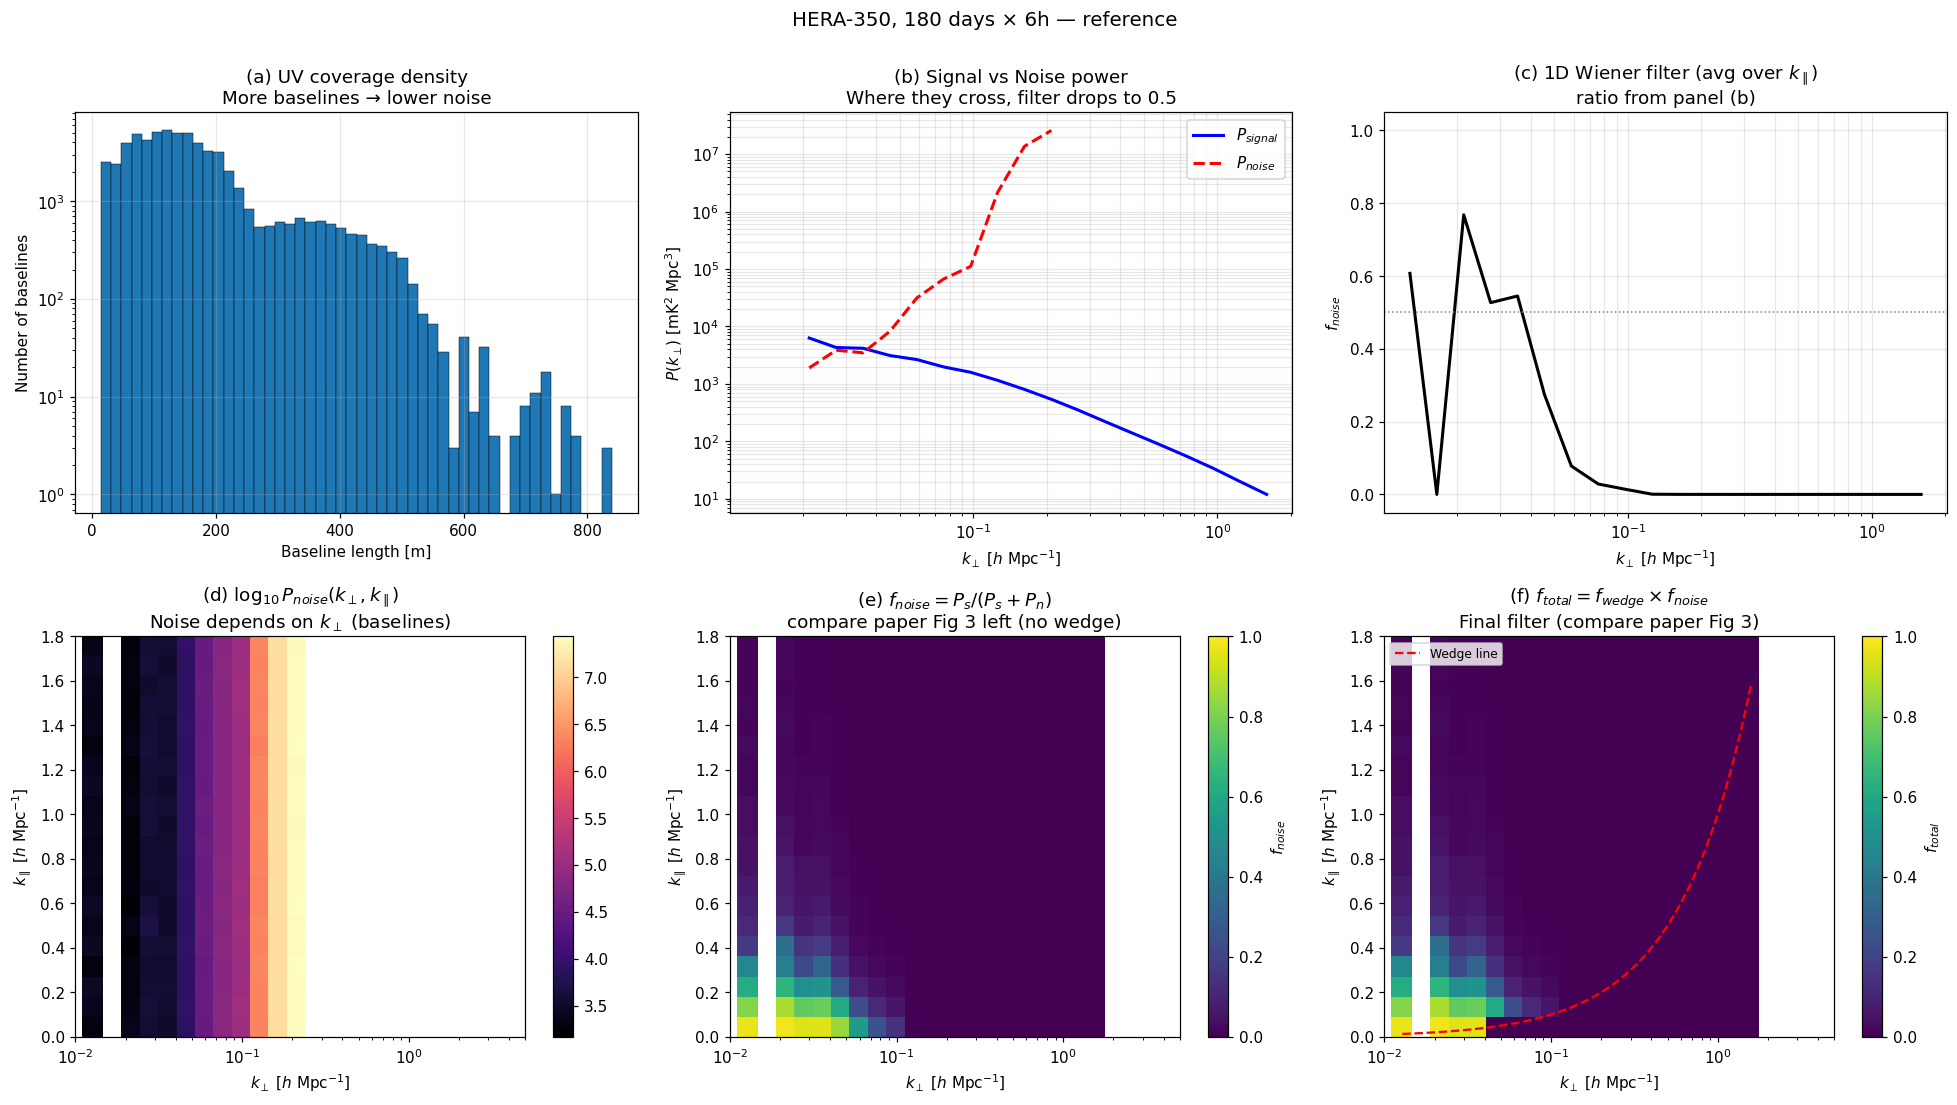

In [15]:
_, obs_ref, antpos_ref = build_hera_observation(
    hex_num=11, split_core=True, outriggers=2,
    dish_size_m=14.0, track_hours=6.0, time_per_day_hours=6.0, n_days=180,
)

fig_ref, out_ref = make_six_panel(
    obs_ref, antpos_ref, kp_c, kpar_c, P_signal, cnt,
    ncells=bt.shape[0],
    suptitle='HERA-350, 180 days × 6h — reference',
)
fig_ref.savefig('../plots/sweep_reference.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Sweep 1 — Array size (`hex_num`)

Fewer/more antennas → fewer/more baselines → different UV coverage density.

finding redundancies: 11175ants [00:00, 1395852.98ants/s]
/var/folders/90/xdq542m92j92bx1klmldh0l40000gn/T/ipykernel_22182/3613952839.py:41: RuntimeWarning: Mean of empty slice
  P_sig_1d = np.nanmean(P_signal, axis=1)


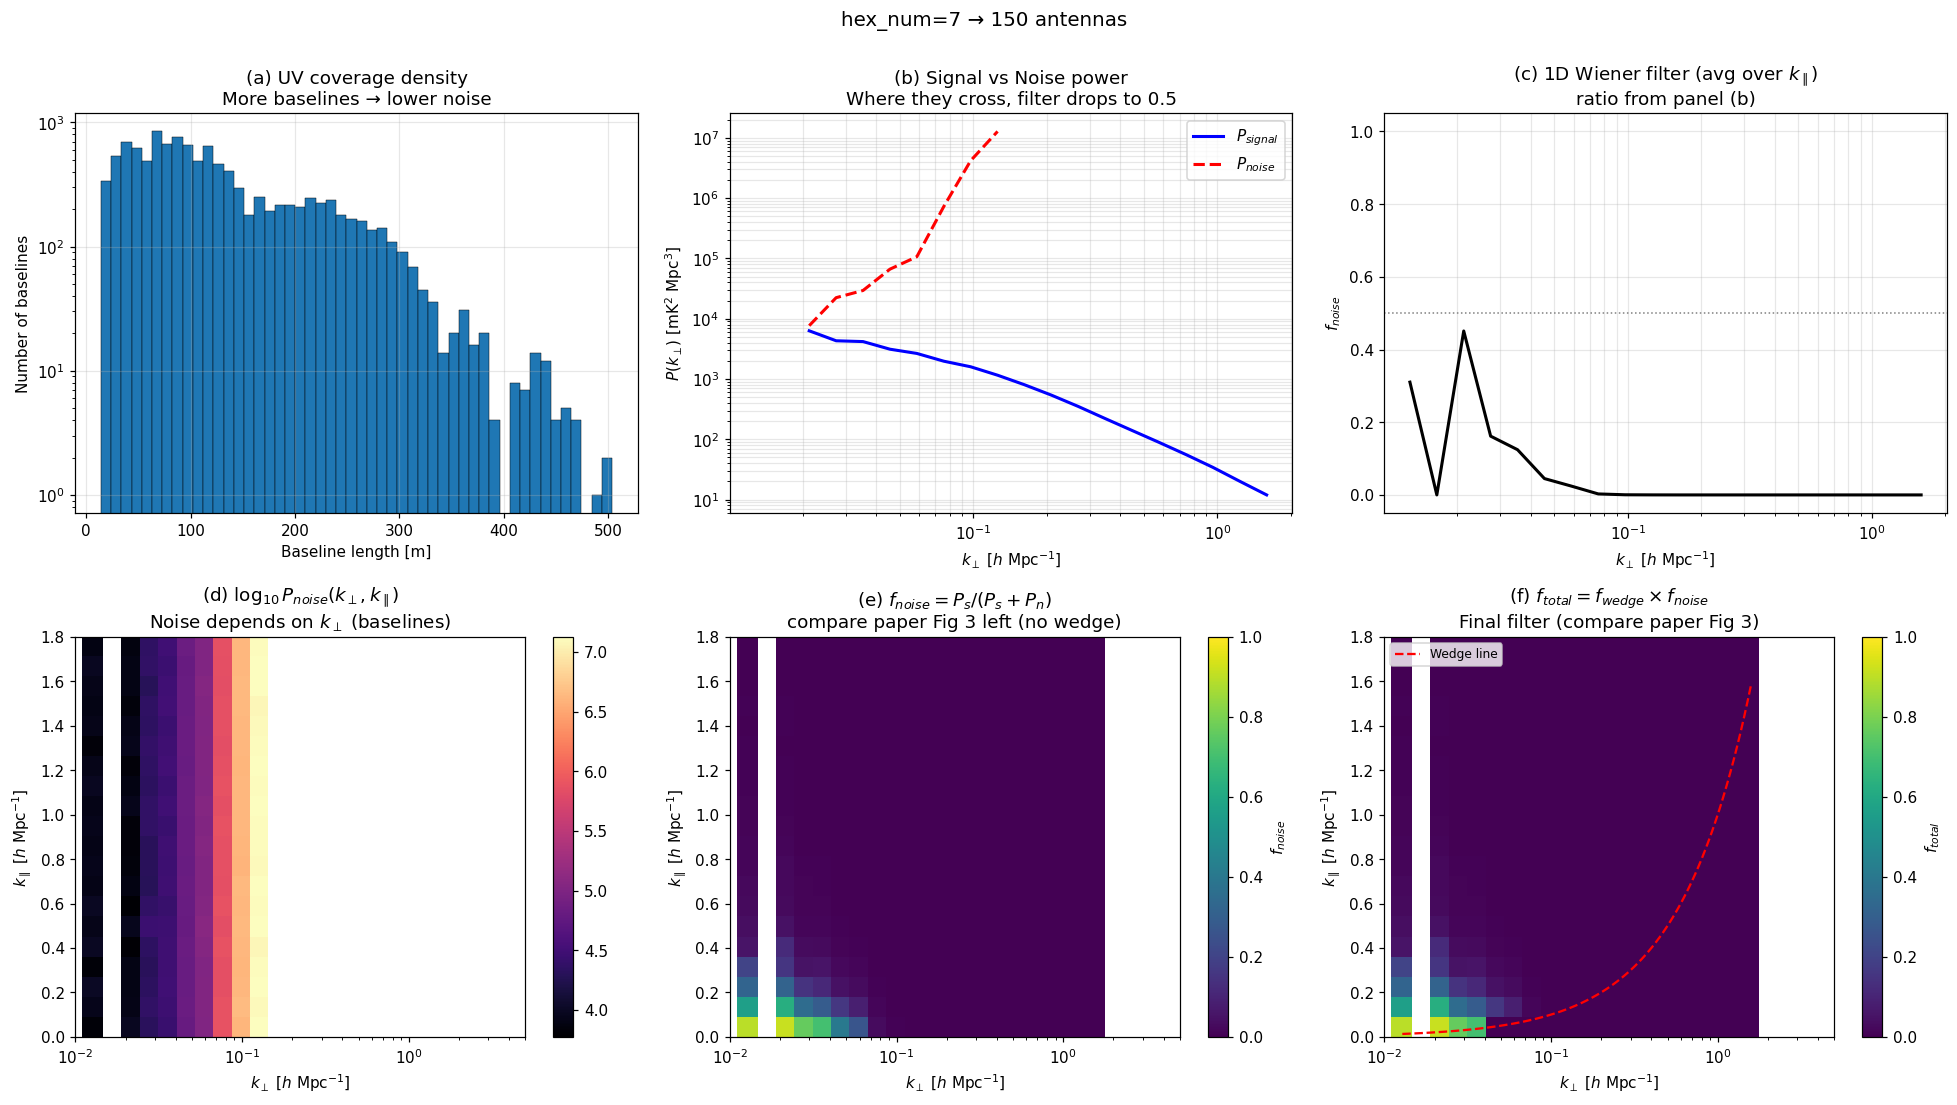

finding redundancies: 61075ants [00:00, 689429.32ants/s]


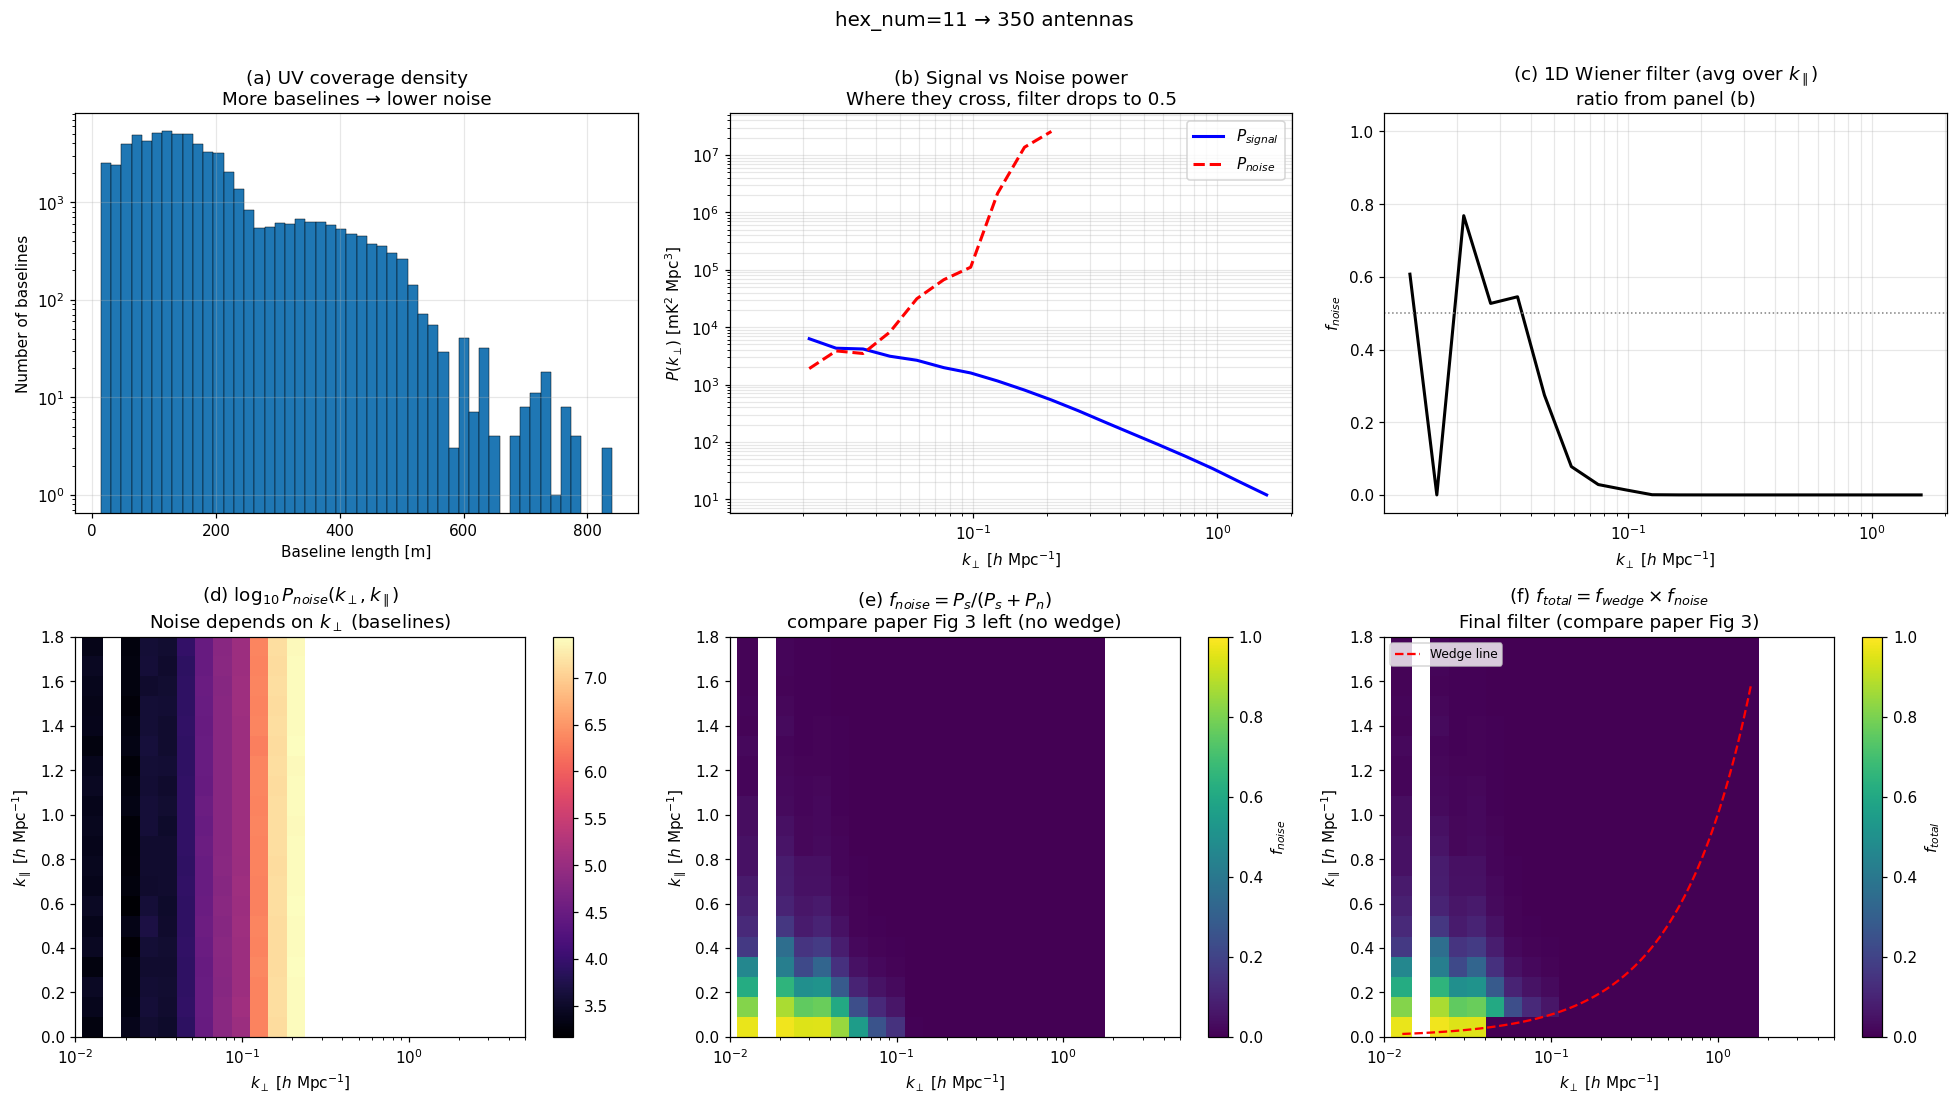

finding redundancies: 208335ants [00:00, 1252878.81ants/s]


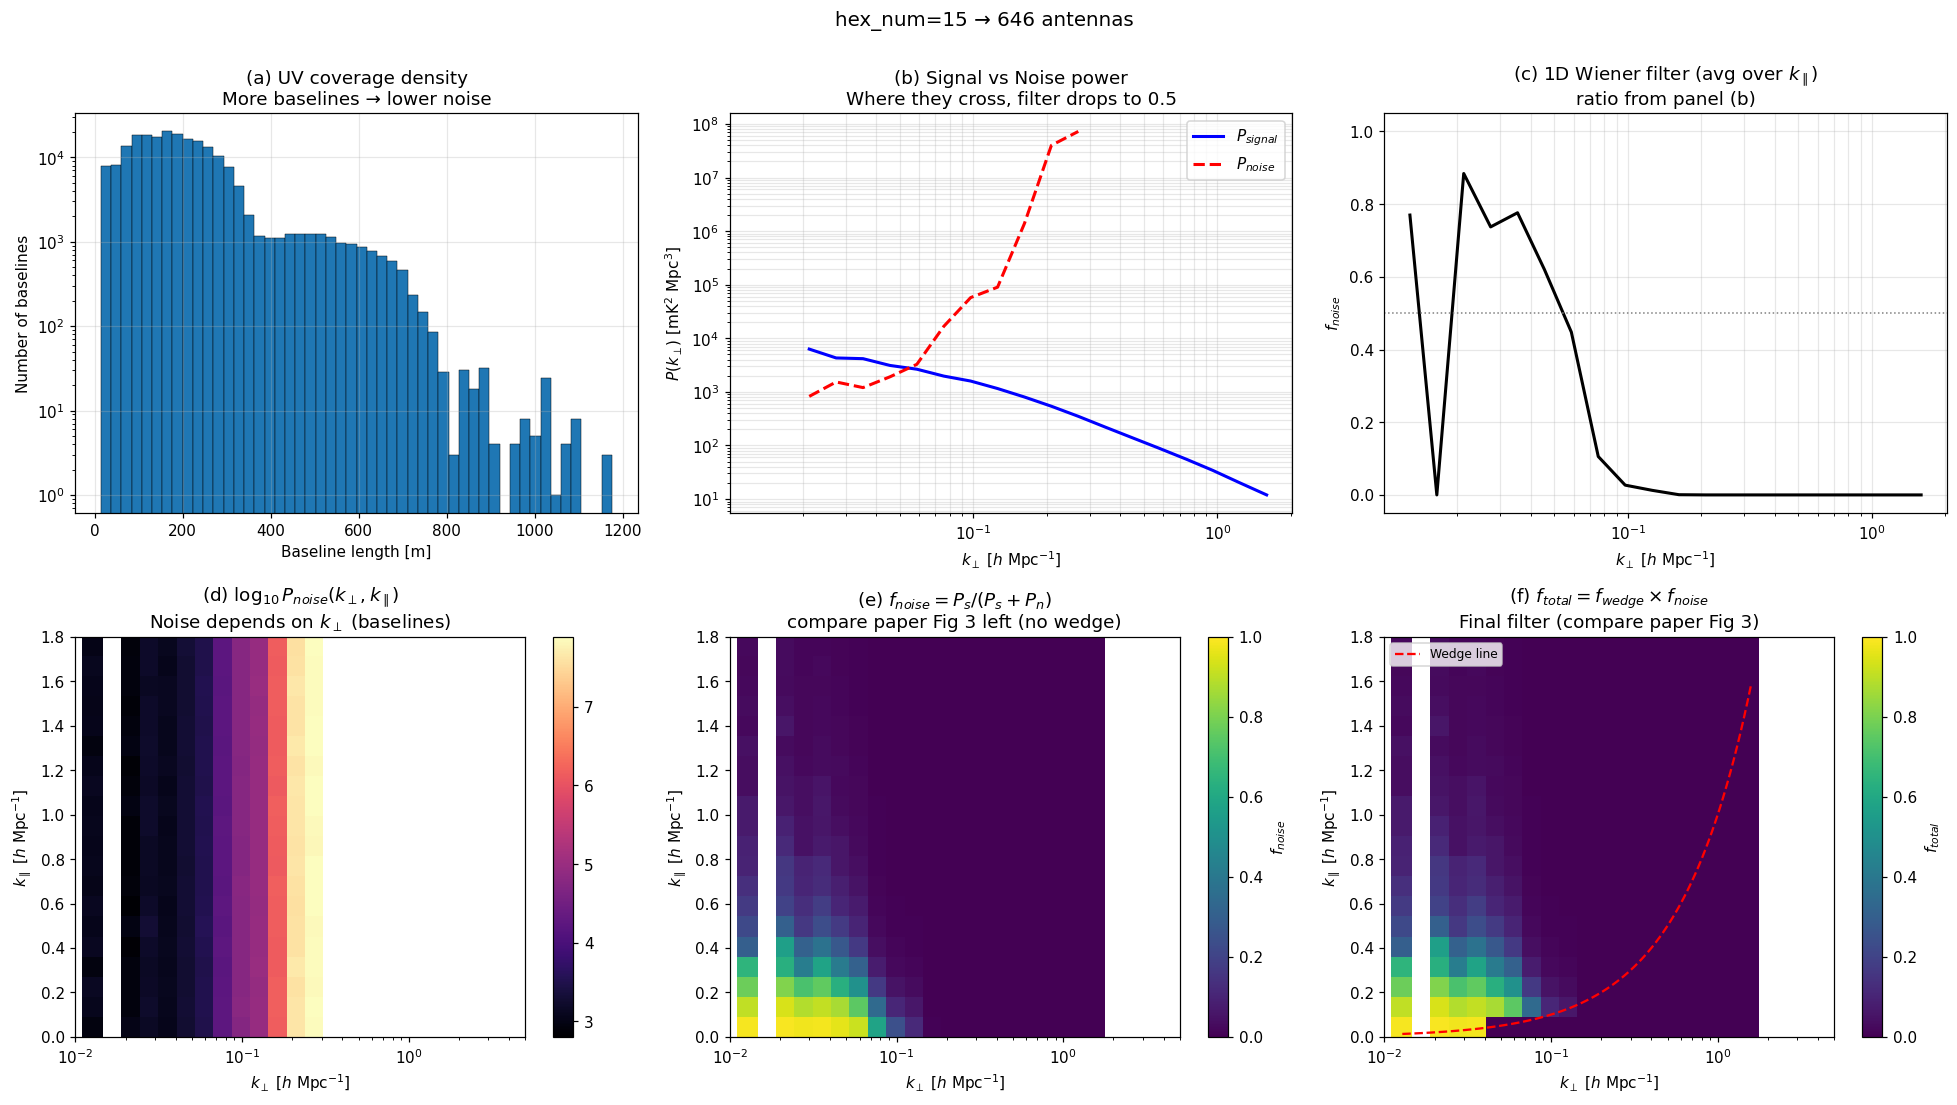

In [16]:
for hex_num in [7, 11, 15]:
    _, obs_i, antpos_i = build_hera_observation(hex_num=hex_num)
    n_ant = len(antpos_i)
    fig_i, _ = make_six_panel(
        obs_i, antpos_i, kp_c, kpar_c, P_signal, cnt,
        ncells=bt.shape[0],
        suptitle=f'hex_num={hex_num} → {n_ant} antennas',
    )
    fig_i.savefig(f'../plots/sweep_hex_{hex_num}.png', dpi=120, bbox_inches='tight')
    plt.show()

## 5. Sweep 2 — Integration time (`n_days`)

Shorter observations have higher noise (σ² ∝ 1/t_int).

finding redundancies: 61075ants [00:00, 1692111.82ants/s]
/var/folders/90/xdq542m92j92bx1klmldh0l40000gn/T/ipykernel_22182/3613952839.py:41: RuntimeWarning: Mean of empty slice
  P_sig_1d = np.nanmean(P_signal, axis=1)


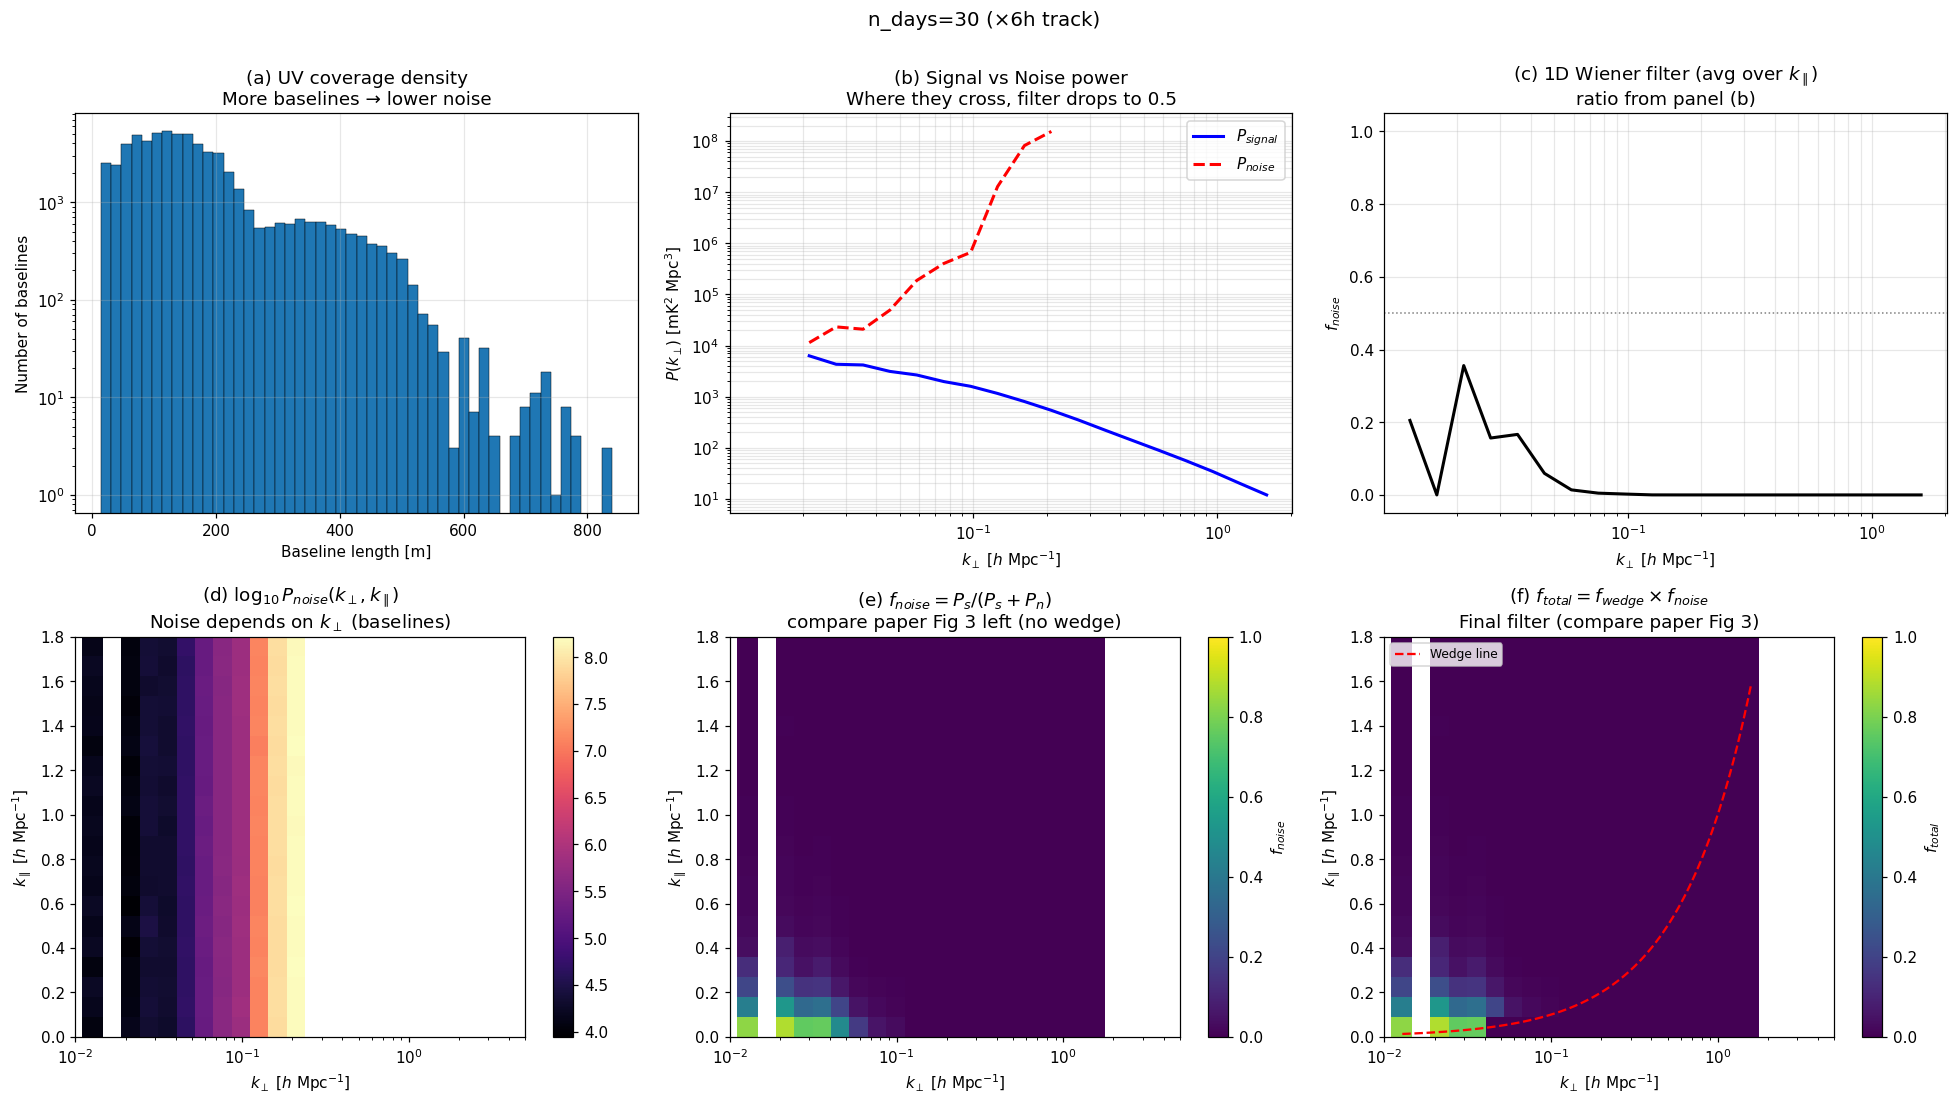

finding redundancies: 61075ants [00:00, 2135188.60ants/s]


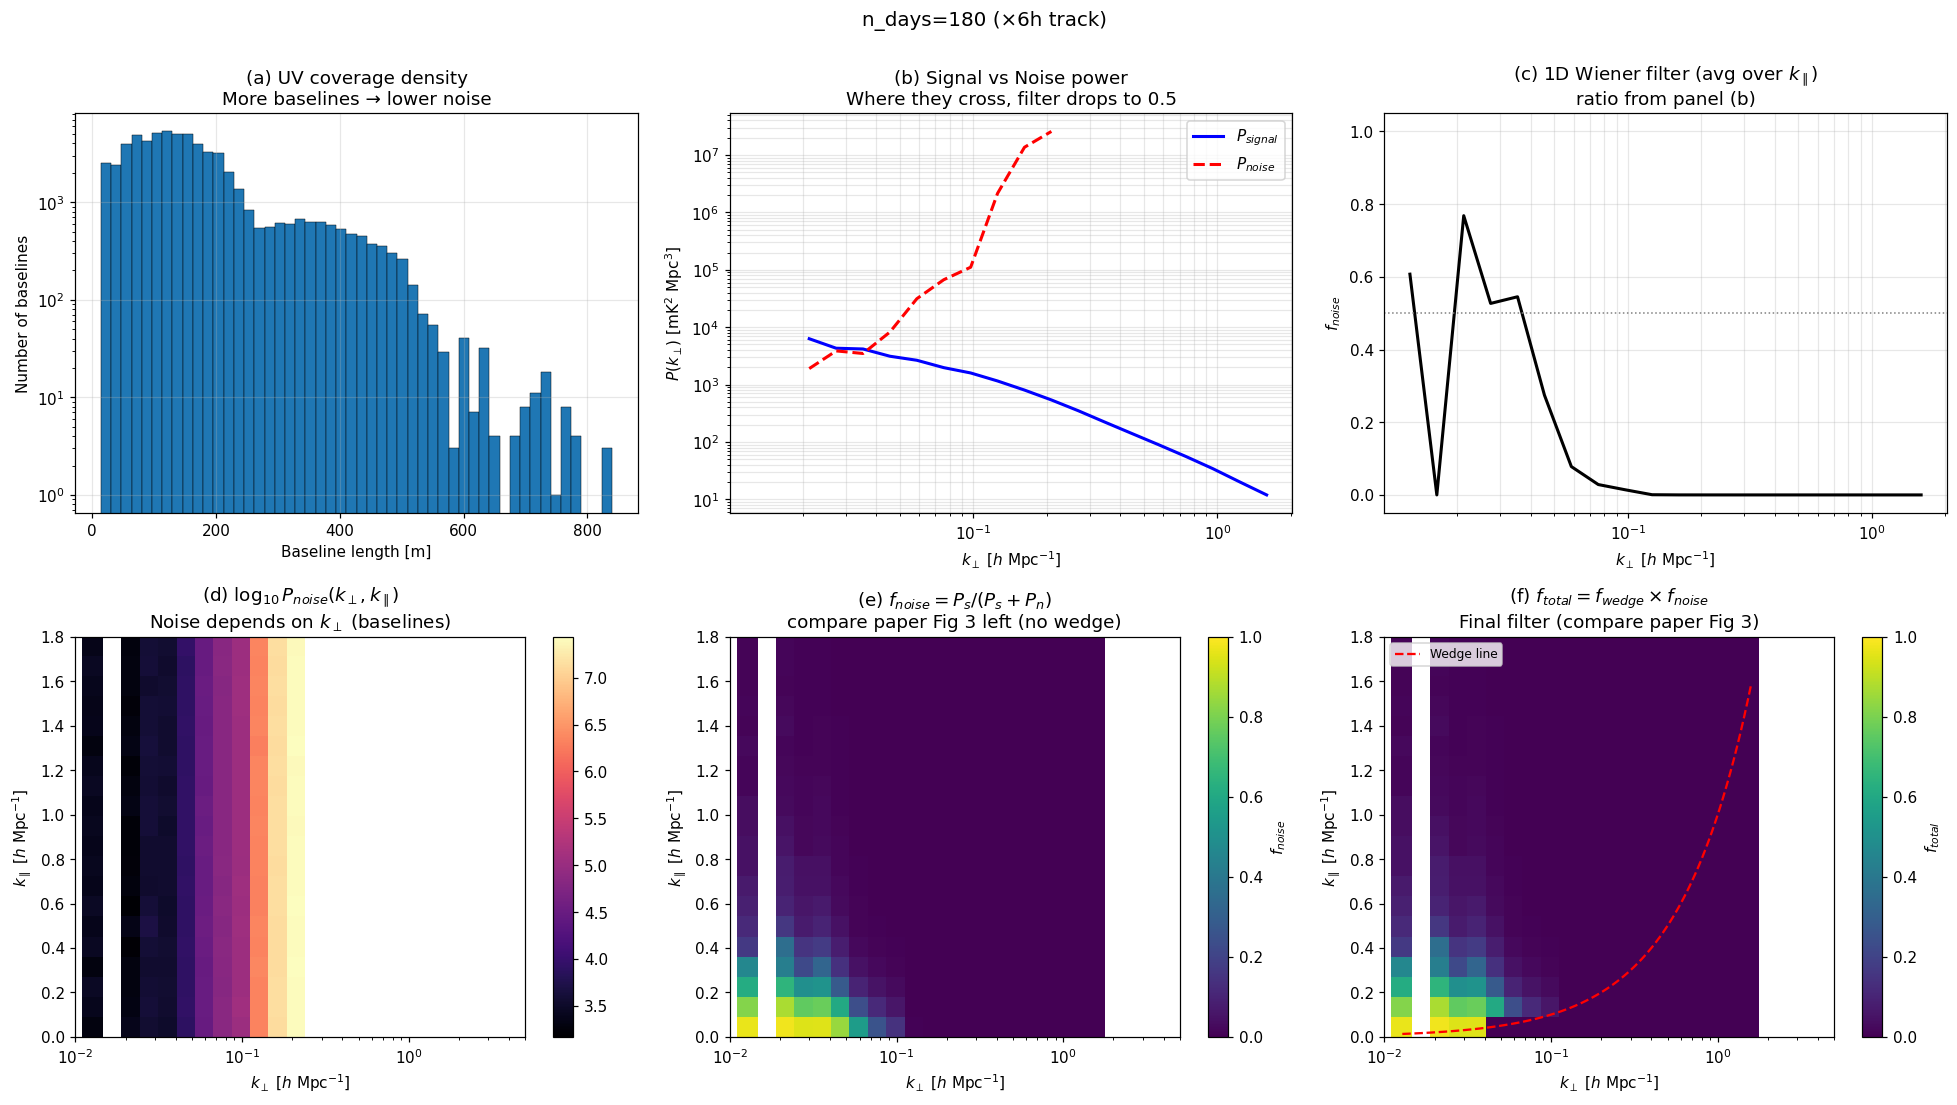

finding redundancies: 61075ants [00:00, 1964471.75ants/s]


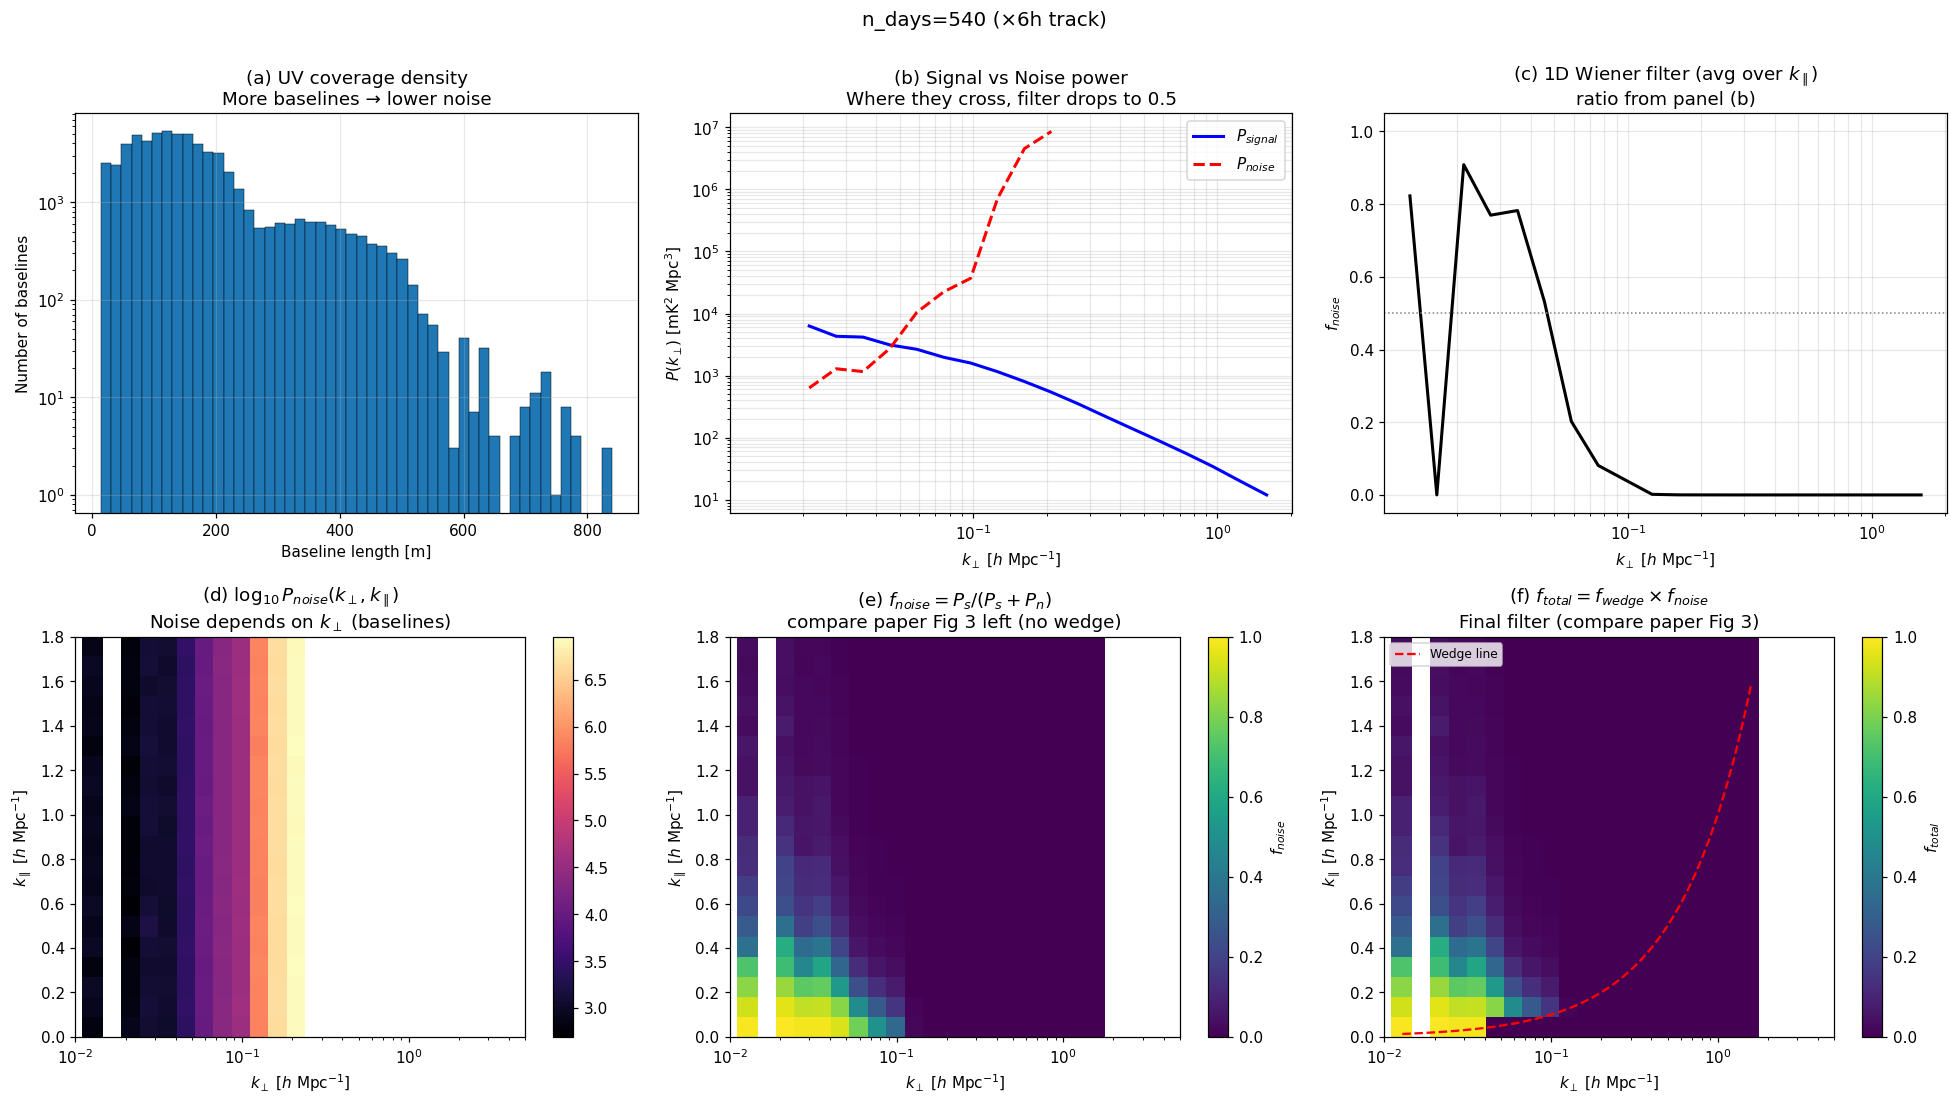

In [17]:
for n_days in [30, 180, 540]:
    _, obs_i, antpos_i = build_hera_observation(n_days=n_days)
    fig_i, _ = make_six_panel(
        obs_i, antpos_i, kp_c, kpar_c, P_signal, cnt,
        ncells=bt.shape[0],
        suptitle=f'n_days={n_days} (×6h track)',
    )
    fig_i.savefig(f'../plots/sweep_days_{n_days}.png', dpi=120, bbox_inches='tight')
    plt.show()

## 6. Sweep 3 — Dish size

Smaller dishes → wider primary beam → lower noise per baseline,
but less collecting area per antenna.

finding redundancies: 61075ants [00:00, 1735384.97ants/s]
/var/folders/90/xdq542m92j92bx1klmldh0l40000gn/T/ipykernel_22182/3613952839.py:41: RuntimeWarning: Mean of empty slice
  P_sig_1d = np.nanmean(P_signal, axis=1)


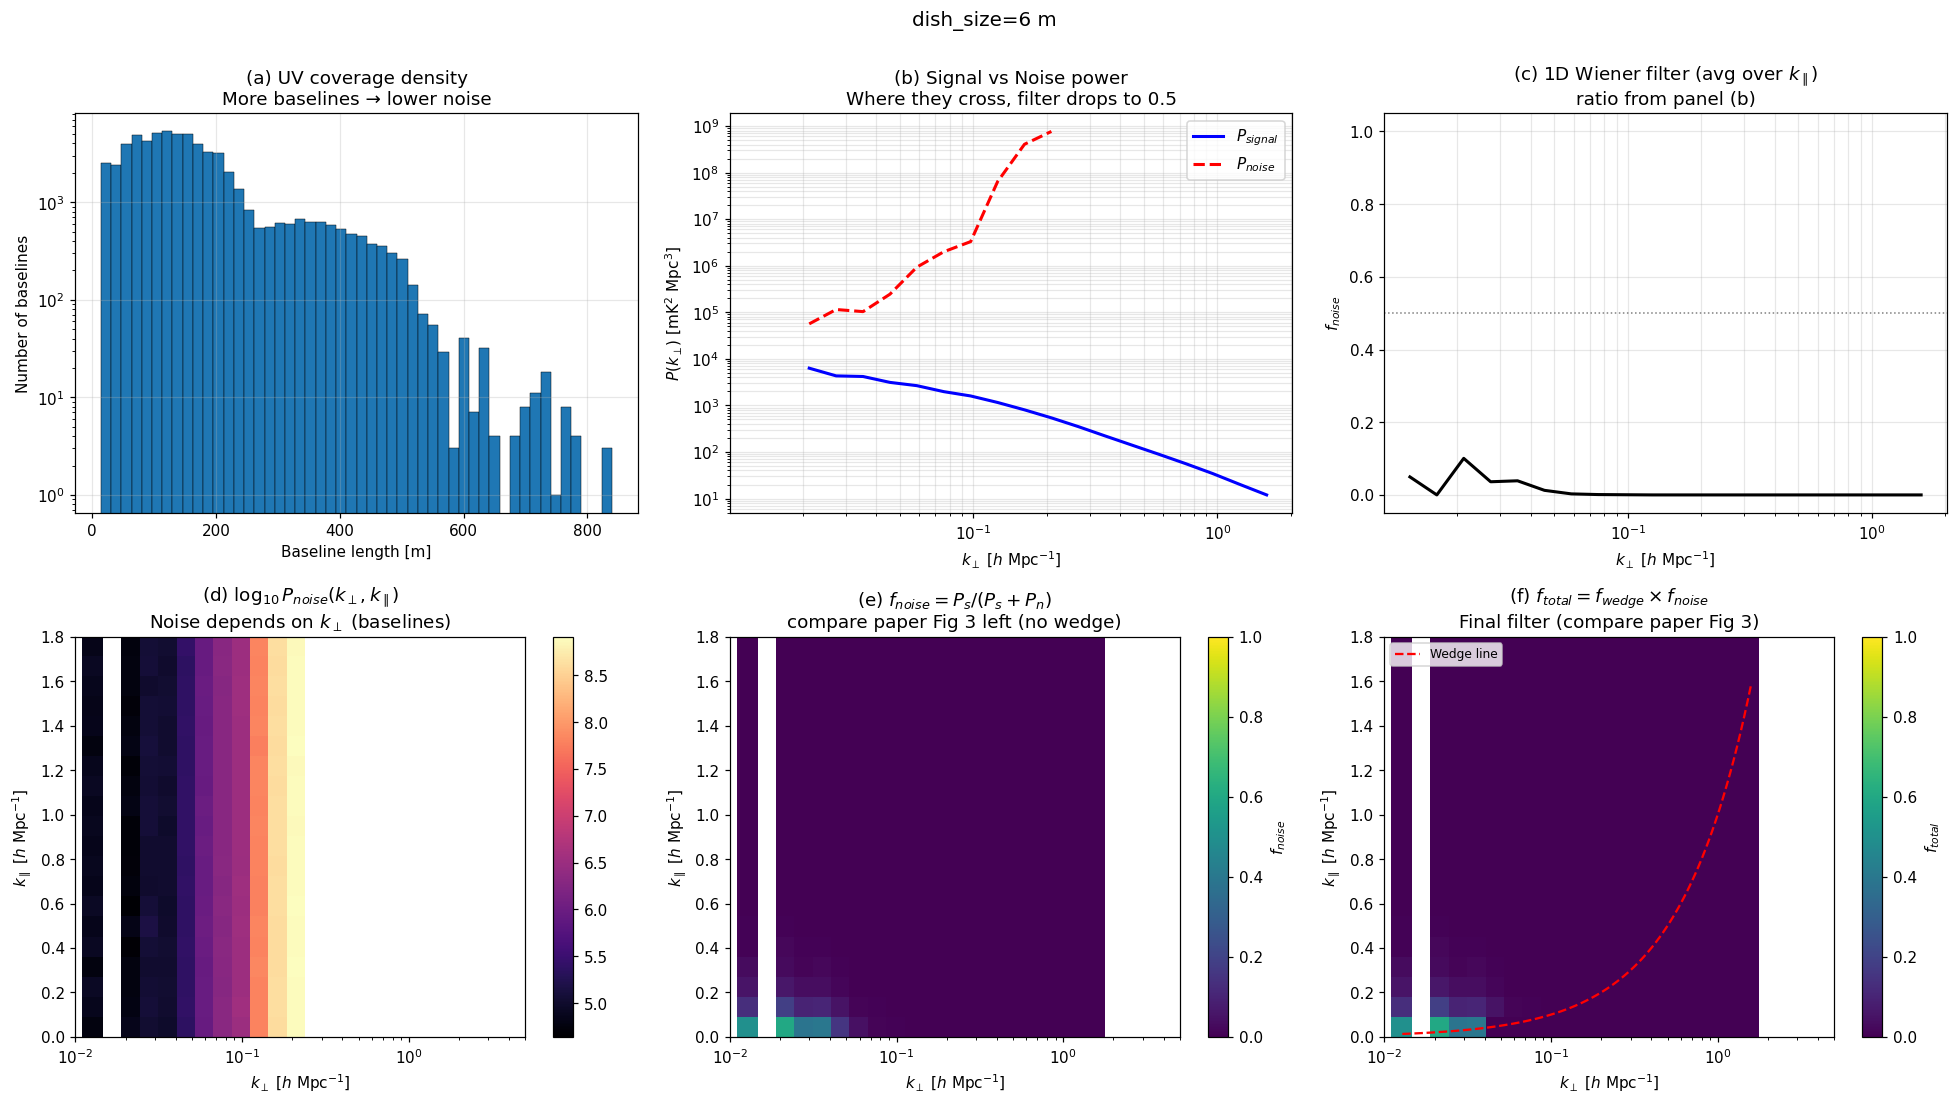

finding redundancies: 61075ants [00:00, 2327014.98ants/s]


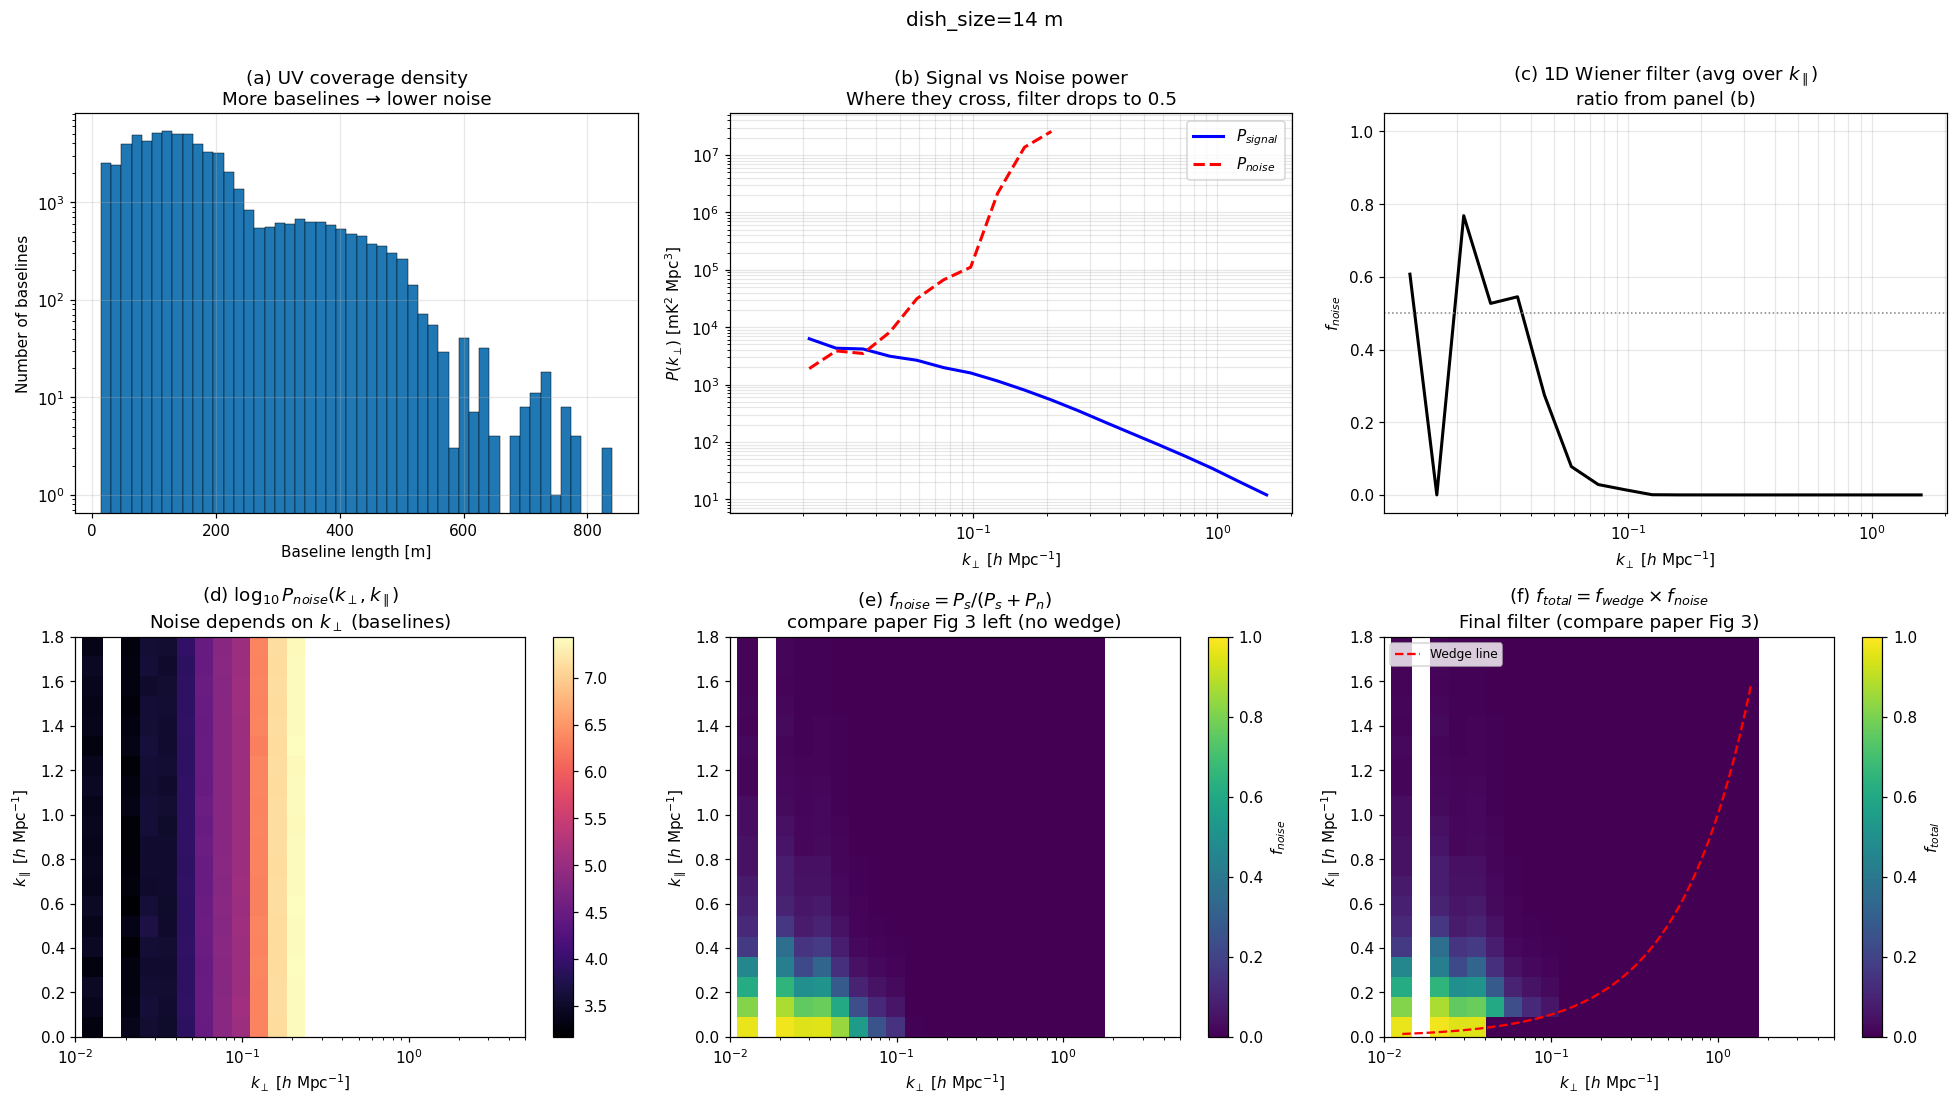

finding redundancies: 61075ants [00:00, 1386305.72ants/s]


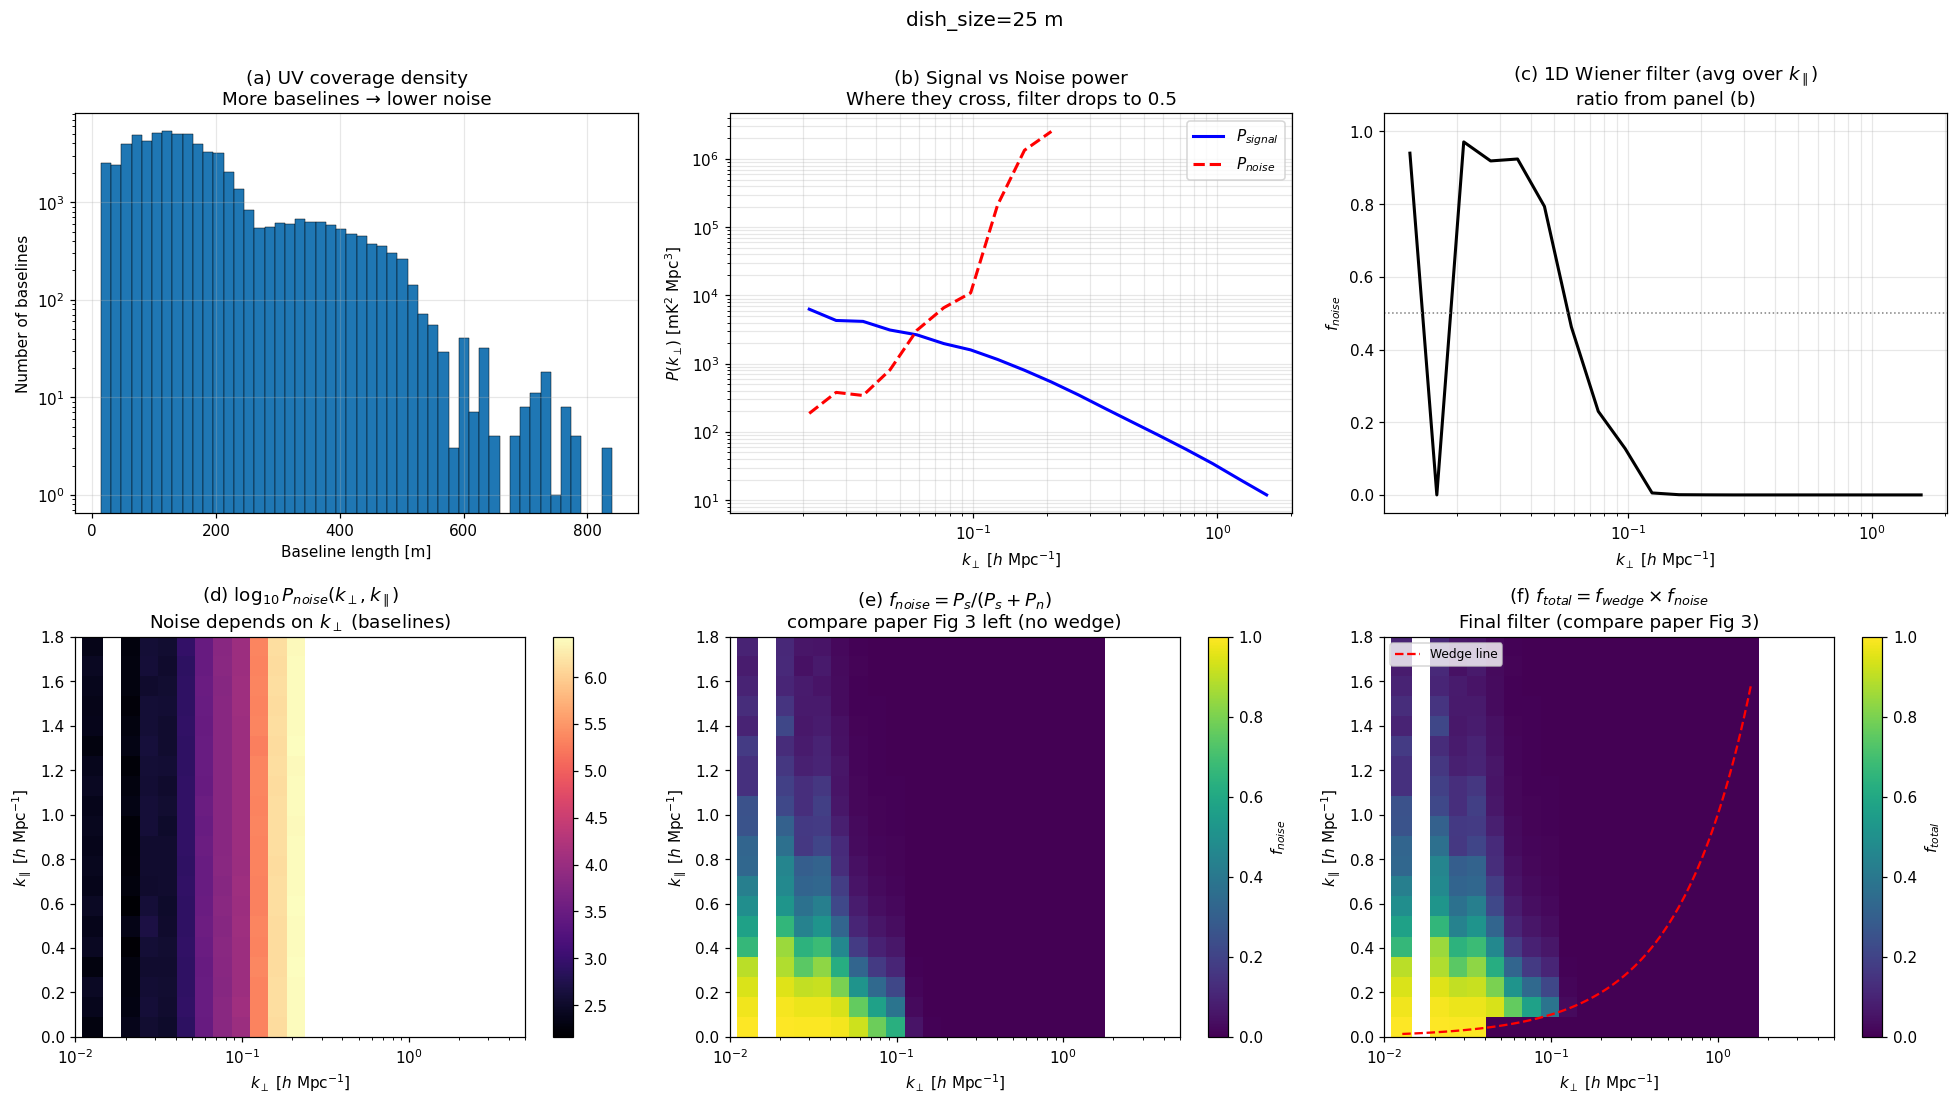

In [18]:
for dish_size in [6.0, 14.0, 25.0]:
    _, obs_i, antpos_i = build_hera_observation(dish_size_m=dish_size)
    fig_i, _ = make_six_panel(
        obs_i, antpos_i, kp_c, kpar_c, P_signal, cnt,
        ncells=bt.shape[0],
        suptitle=f'dish_size={dish_size:.0f} m',
    )
    fig_i.savefig(f'../plots/sweep_dish_{int(dish_size)}m.png', dpi=120, bbox_inches='tight')
    plt.show()

## 7. Sweep 4 — Outriggers (long baselines)

Outriggers give longer baselines → access to higher `k_perp`.

finding redundancies: 51040ants [00:00, 2270654.18ants/s]
/var/folders/90/xdq542m92j92bx1klmldh0l40000gn/T/ipykernel_22182/3613952839.py:41: RuntimeWarning: Mean of empty slice
  P_sig_1d = np.nanmean(P_signal, axis=1)


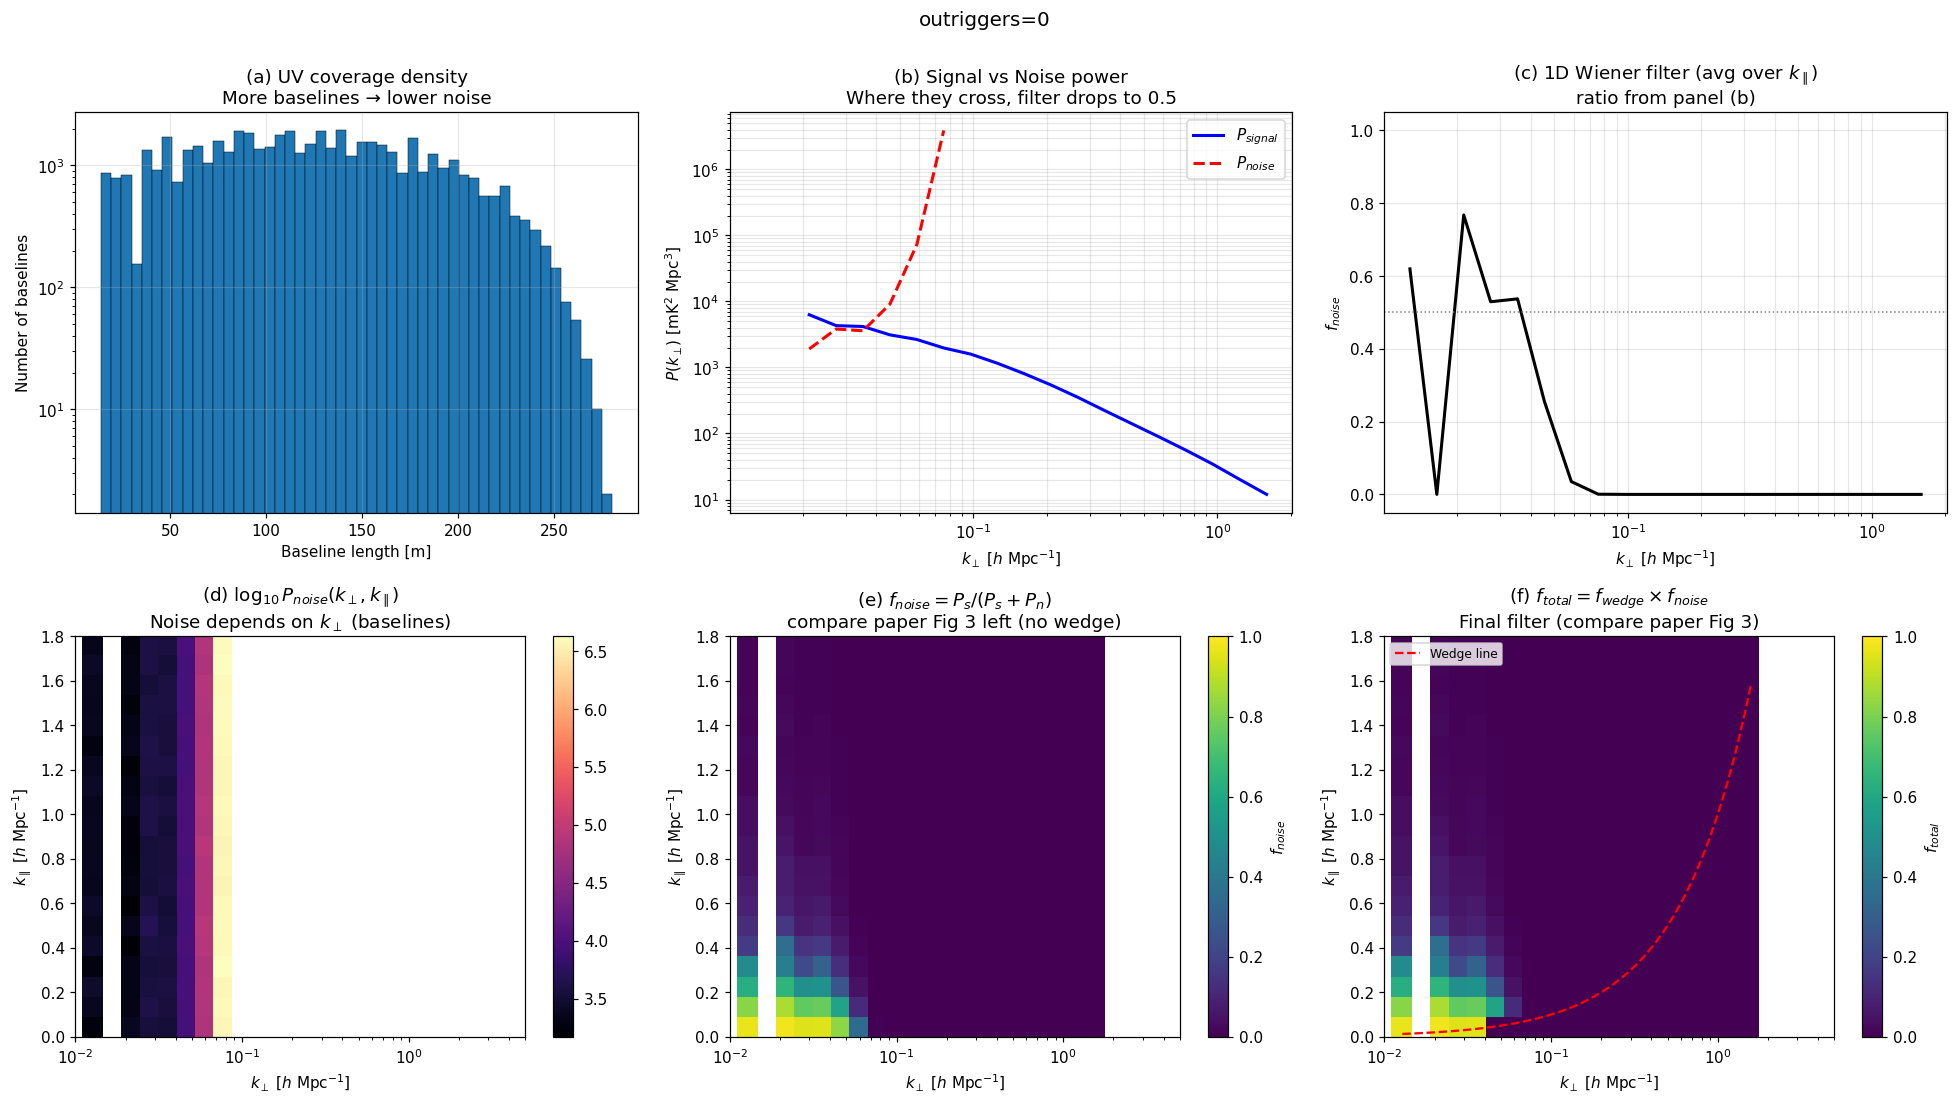

finding redundancies: 54946ants [00:00, 2174276.16ants/s]


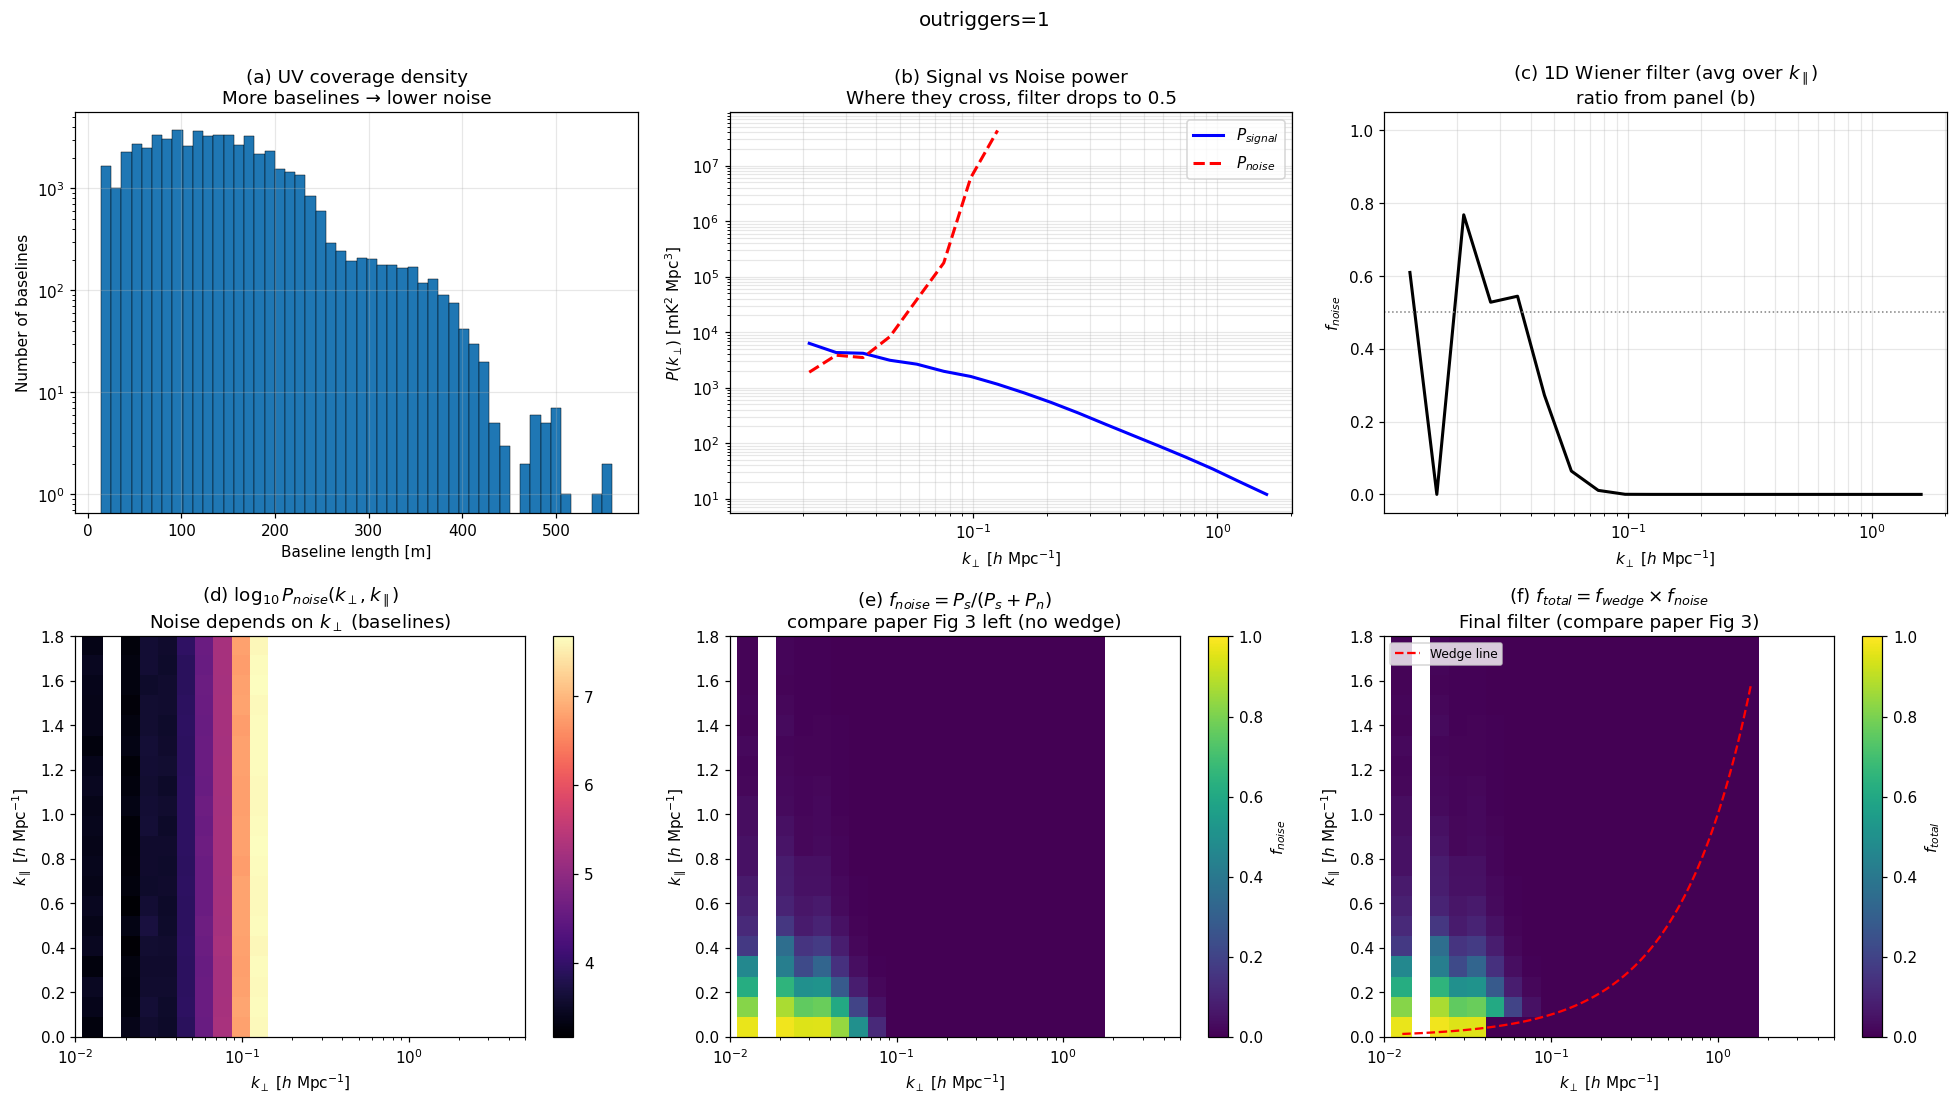

finding redundancies: 61075ants [00:00, 2351580.93ants/s]


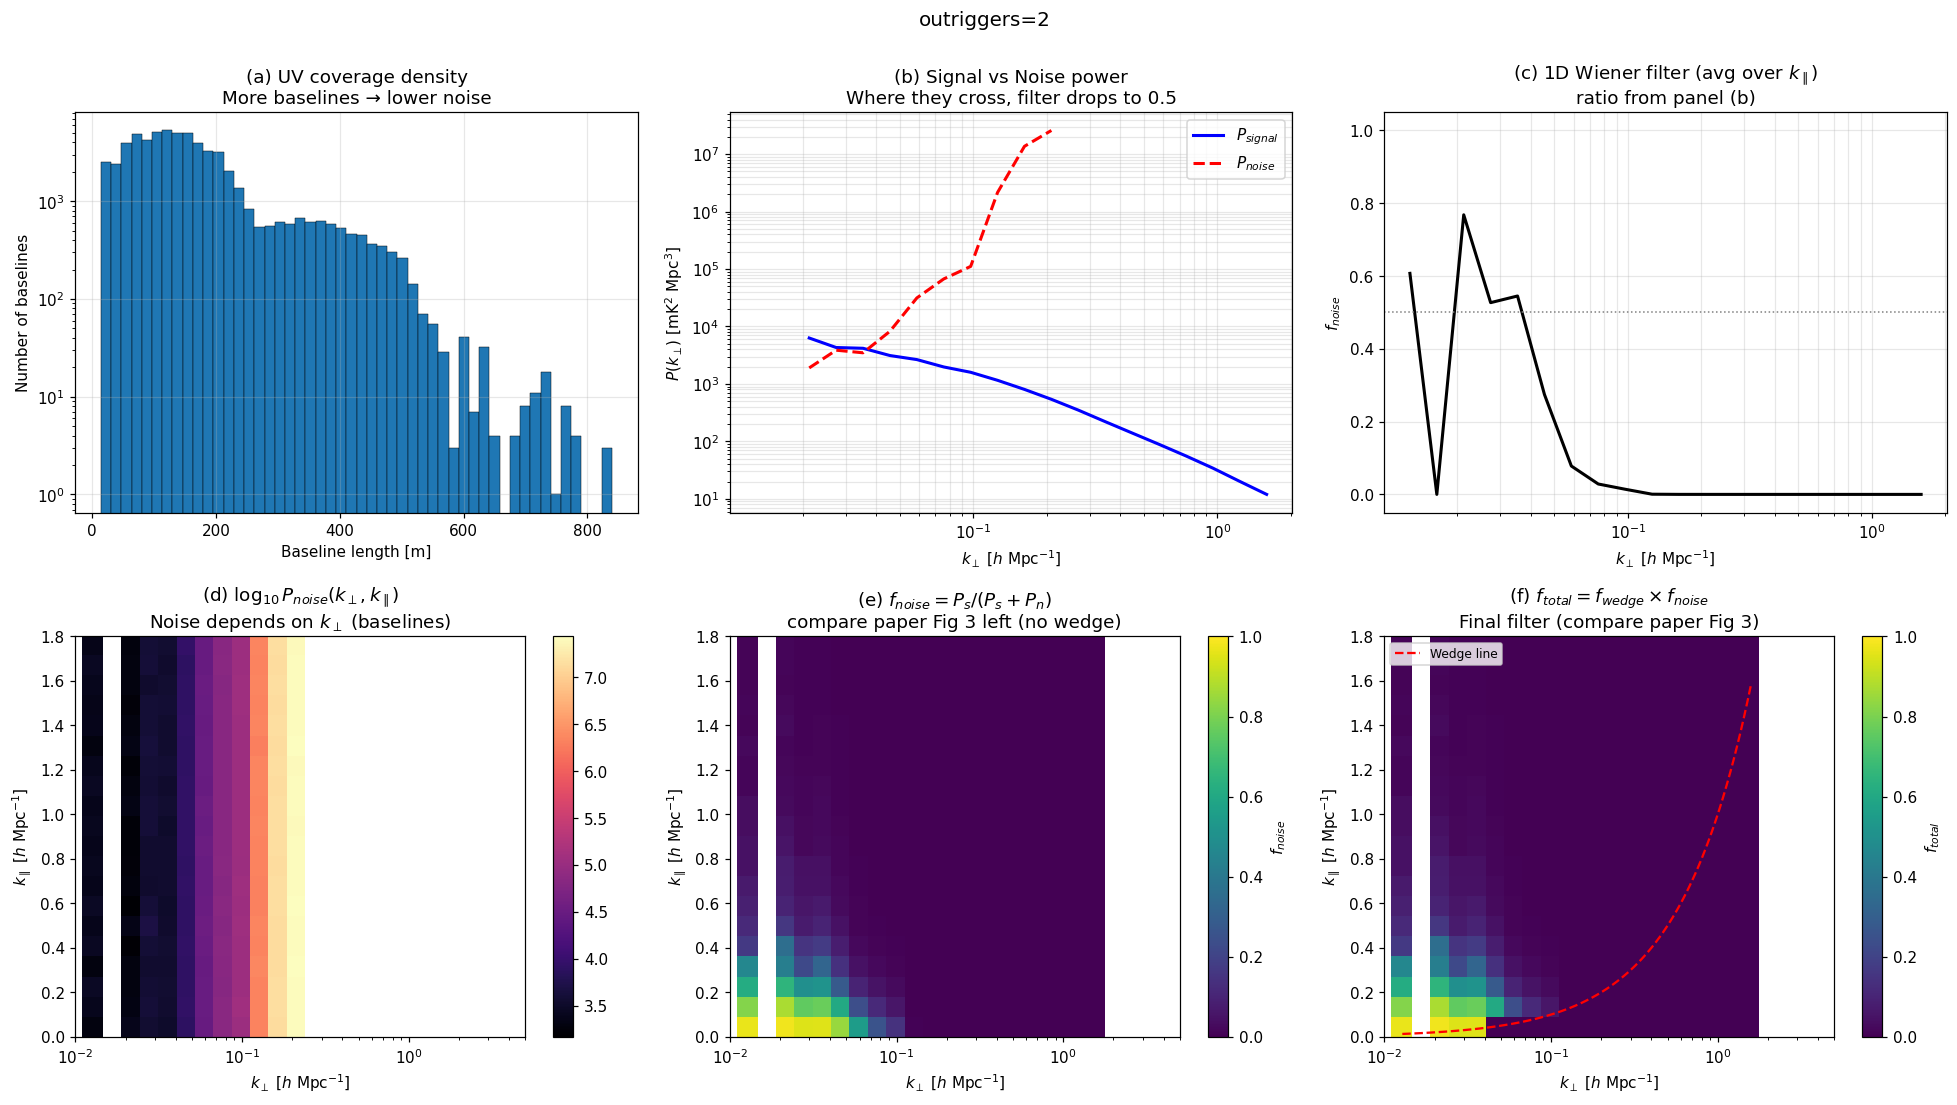

In [19]:
for out in [0, 1, 2]:
    _, obs_i, antpos_i = build_hera_observation(outriggers=out)
    fig_i, _ = make_six_panel(
        obs_i, antpos_i, kp_c, kpar_c, P_signal, cnt,
        ncells=bt.shape[0],
        suptitle=f'outriggers={out}',
    )
    fig_i.savefig(f'../plots/sweep_outriggers_{out}.png', dpi=120, bbox_inches='tight')
    plt.show()

## 8. Summary — compare 2D filters side-by-side

Pull just panel (f) (`f_total`) from each config so you can see the net effect on
surviving modes at a glance.

finding redundancies: 11175ants [00:00, 2008456.41ants/s]
finding redundancies: 61075ants [00:00, 2322247.46ants/s]
finding redundancies: 208335ants [00:00, 2328492.39ants/s]
finding redundancies: 61075ants [00:00, 2469485.28ants/s]
finding redundancies: 61075ants [00:00, 2470557.02ants/s]
finding redundancies: 51040ants [00:00, 2612705.81ants/s]


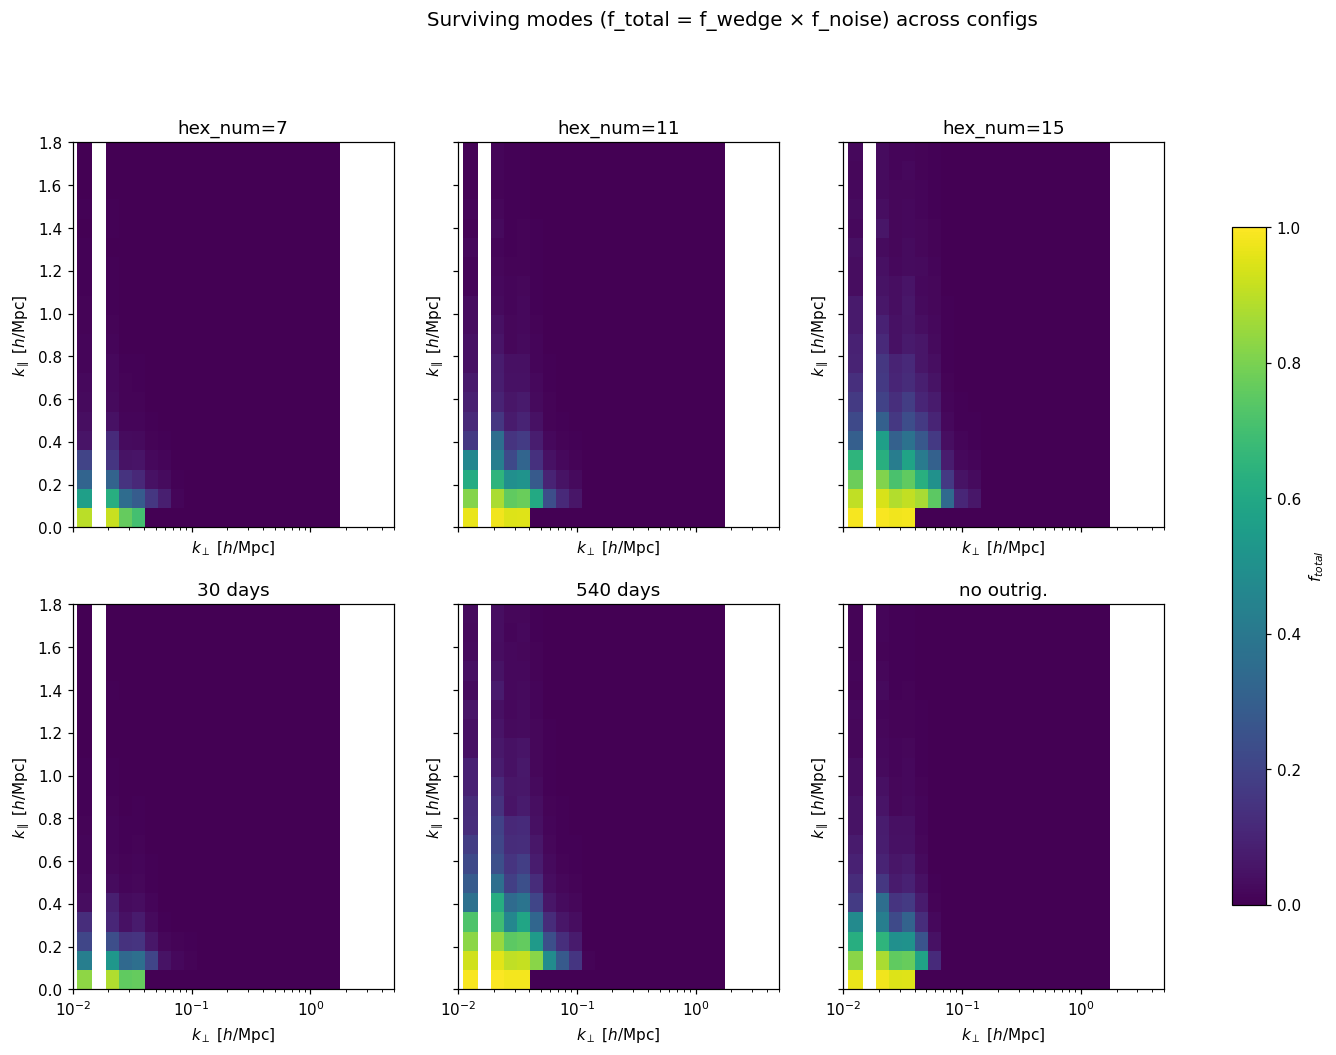

In [20]:
configs = [
    ('hex_num=7',   dict(hex_num=7)),
    ('hex_num=11',  dict(hex_num=11)),
    ('hex_num=15',  dict(hex_num=15)),
    ('30 days',     dict(n_days=30)),
    ('540 days',    dict(n_days=540)),
    ('no outrig.',  dict(outriggers=0)),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)
for ax, (label, cfg) in zip(axes.flat, configs):
    _, obs_i, antpos_i = build_hera_observation(**cfg)
    _, _, P_n_2d, _ = empirical_noise_2d(
        obs_i, (bt.shape[0],)*3, BOX_LEN, REDSHIFT,
        n_realizations=N_NOISE_REAL,
        n_bins_perp=len(kp_c), n_bins_par=len(kpar_c),
    )
    f_n = wiener_filter(P_signal, P_n_2d)
    f_n[cnt < 3] = np.nan
    f_tot = f_n * wedge_mask(kp_c, kpar_c, slope=WEDGE_SLOPE)

    im = ax.pcolormesh(kp_c * H_PARAM, kpar_c * H_PARAM, f_tot.T,
                        cmap='viridis', vmin=0, vmax=1, shading='auto')
    ax.set_xscale('log')
    ax.set_xlim(1e-2, 5)
    ax.set_ylim(0, 1.8)
    ax.set_title(label)
    ax.set_xlabel(r'$k_\perp$ [$h$/Mpc]')
    ax.set_ylabel(r'$k_\parallel$ [$h$/Mpc]')

fig.colorbar(im, ax=axes, label=r'$f_{total}$', shrink=0.8)
fig.suptitle('Surviving modes (f_total = f_wedge × f_noise) across configs',
             fontsize=13, y=1.00)
plt.savefig('../plots/sweep_summary.png', dpi=150, bbox_inches='tight')
plt.show()